# Tutorial 2: Multi-condition Analysis of Kidney Atlas

This tutorial demonstrates multi-condition spatial analysis using the CZI Kidney Atlas (MERFISH).
The dataset includes four conditions — ADTKD (autosomal dominant tubulointerstitial kidney disease),
DKD (early diabetic kidney disease), and their respective controls — enabling cross-condition
comparison of spatial organization patterns.

We cover motif enrichment per condition, differential motif analysis, targeted motif testing,
differential expression of motif-associated cells, and cross-cell gene-gene covariation.

**API class:** `spatial_query_multi`

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from SpatialQuery import spatial_query_multi

## 2. Load Data & Preprocessing

Load the kidney atlas h5ad files, create disease–genotype condition labels,
and filter out mitochondrial and unannotated genes.

In [3]:
DATA_DIR = "../data/CZI_kidney"

data_files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.h5ad')]
adatas = [ad.read_h5ad(f) for f in data_files]

n_total = sum([adata.n_obs for adata in adatas])
print(f"Total number of cells: {n_total}")

Total number of cells: 2000601


In [4]:
adatas[0]

AnnData object with n_obs × n_vars = 12906 × 17811
    obs: 'assay_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sample', 'tissue_ontology_term_id', 'disease_state', 'sex_ontology_term_id', 'genotype', 'development_stage_ontology_term_id', 'author_cell_type', 'cell_type_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length'
    uns: 'citation', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_spatial'

In [6]:
# Create condition labels and filter out mitochondrial / unannotated genes
for i, adata in enumerate(adatas):
    adata.obs['disease_state_genotype'] = (
        adata.obs['disease_state'].astype(str) + '_' + adata.obs['genotype'].astype(str)
    )
    adata.var_names = adata.var['feature_name'].tolist()
    adata = adata[:, ~adata.var_names.str.startswith('mt-')]
    adata = adata[:, ~adata.var_names.str.endswith('Rik')]
    adata = adata[:, ~adata.var_names.str.startswith('Gm')]
    adatas[i] = adata

In [7]:
# Map verbose condition names to short labels
dataset_mapping = {
    'early diabetic kidney disease_BTBR-ob/ob': 'DKD_BTBR-ob/ob',
    'autosomal dominant tubulointersital kidney disease (ADTKD)_UMOD-KI/KI': 'ADTKD_UMOD-KI/KI',
    'control_BTBR-wt/wt': 'control_BTBR-WT/WT',
    'control_UMOD-WT/WT': 'control_UMOD-WT/WT',
}

dataset_name_col = 'disease_state_genotype'
datasets = [adata.obs[dataset_name_col].unique()[0] for adata in adatas]
dataset_names = [dataset_mapping[d] for d in datasets]


## 3. Initialize SpatialQuery Multi

In [8]:
# ---- Configuration: adjust these to match your dataset ----
spatial_key = "X_spatial"
label_key = "cell_type"
feature_name = "feature_name"

In [9]:
spm = spatial_query_multi(
    adatas,
    datasets=dataset_names,
    spatial_key=spatial_key,
    label_key=label_key,
    feature_name=feature_name,
    build_gene_index=False,
    if_lognorm=True,
    if_normalize_spatial_coord=True,
)

Replacing _ with hyphen in DKD_BTBR-ob/ob.
Replacing _ with hyphen in DKD_BTBR-ob/ob.
Replacing _ with hyphen in control_BTBR-WT/WT.
Replacing _ with hyphen in control_UMOD-WT/WT.
Replacing _ with hyphen in ADTKD_UMOD-KI/KI.
Replacing _ with hyphen in ADTKD_UMOD-KI/KI.
Replacing _ with hyphen in ADTKD_UMOD-KI/KI.
Replacing _ with hyphen in control_BTBR-WT/WT.
Replacing _ with hyphen in control_BTBR-WT/WT.
Replacing _ with hyphen in DKD_BTBR-ob/ob.
... (492 lines omitted) ...
build_gene_index is False. Using adata.X for gene expression analysis.
Log normalizing the expression data... If data is already log normalized, please set if_lognorm to False.


In [10]:
valid_ds_names = list(set(s.dataset.split('_')[0] for s in spm.spatial_queries))
valid_ds_names

['DKD-BTBR-ob/ob',
 'control-UMOD-WT/WT',
 'control-BTBR-WT/WT',
 'ADTKD-UMOD-KI/KI']

## 4. Cell Type Composition

/Users/sa3520/BWH/spatial query/python/SpatialQuery/spatial_query_multiple_fov.py:1441: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(colormap)


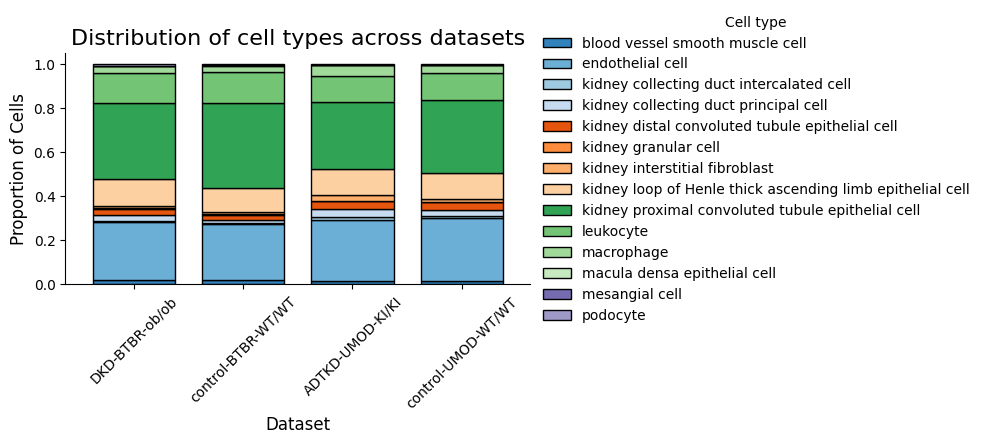

In [12]:
spm.plot_cell_type_distribution()

## 5. Motif Enrichment by Condition

Discover enriched motifs surrounding **macrophages** in each condition separately.

In [13]:
anchor_ct = 'macrophage'
max_dist = 5
min_support = 0.3

enrich_motif_dataset = dict()

for ds in valid_ds_names:
    enrich_motif_dataset[ds] = spm.motif_enrichment_dist(
        ct=anchor_ct,
        dataset=ds,
        max_dist=max_dist,
        min_support=min_support,
        return_cellID=False
    )
    print(f"Found {len(enrich_motif_dataset[ds])} enriched motifs in {ds}")
    
enrich_motif_dataset_df = pd.DataFrame()
for ds, df in enrich_motif_dataset.items():
    df['dataset'] = ds
    enrich_motif_dataset_df = pd.concat([enrich_motif_dataset_df, df], axis=0)
    

Found 6 enriched motifs in DKD-BTBR-ob/ob
Found 4 enriched motifs in control-UMOD-WT/WT
Found 5 enriched motifs in control-BTBR-WT/WT
Found 2 enriched motifs in ADTKD-UMOD-KI/KI


In [14]:
enrich_motif_dataset_df

,center,motifs,n_center_motif,n_center,n_motif,expectation,p-values,adj-pval,if_significant,dataset
0,macrophage,"[endothelial cell, kidney loop of Henle thick ...",10440,19788,201130,6489.238746,0.000000e+00,0.000000e+00,True,DKD-BTBR-ob/ob
1,macrophage,"[endothelial cell, kidney proximal convoluted ...",7990,19788,183346,5915.457501,1.782429e-223,5.347287e-223,True,DKD-BTBR-ob/ob
2,macrophage,"[kidney collecting duct principal cell, leukoc...",5949,19788,126952,4095.966973,1.925776e-219,3.851553e-219,True,DKD-BTBR-ob/ob
3,macrophage,"[endothelial cell, kidney collecting duct prin...",6384,19788,141963,4580.280416,4.511277e-195,6.766915e-195,True,DKD-BTBR-ob/ob
4,macrophage,"[endothelial cell, kidney loop of Henle thick ...",6054,19788,134374,4335.429659,1.057747e-183,1.269296e-183,True,DKD-BTBR-ob/ob
5,macrophage,"[endothelial cell, kidney loop of Henle thick ...",7718,19788,245408,7917.819829,9.983778e-01,9.983778e-01,False,DKD-BTBR-ob/ob
0,macrophage,"[endothelial cell, kidney loop of Henle thick ...",7499,12569,134378,5024.429305,0.000000e+00,0.000000e+00,True,control-UMOD-WT/WT
1,macrophage,"[endothelial cell, kidney interstitial fibrobl...",3803,12569,79991,2990.884851,2.444011e-64,4.888022e-64,True,control-UMOD-WT/WT
2,macrophage,"[endothelial cell, kidney proximal convoluted ...",3823,12569,96950,3624.986390,3.670769e-05,4.894359e-05,True,control-UMOD-WT/WT
3,macrophage,"[endothelial cell, kidney proximal convoluted ...",5124,12569,181365,6781.285783,1.000000e+00,1.000000e+00,False,control-UMOD-WT/WT


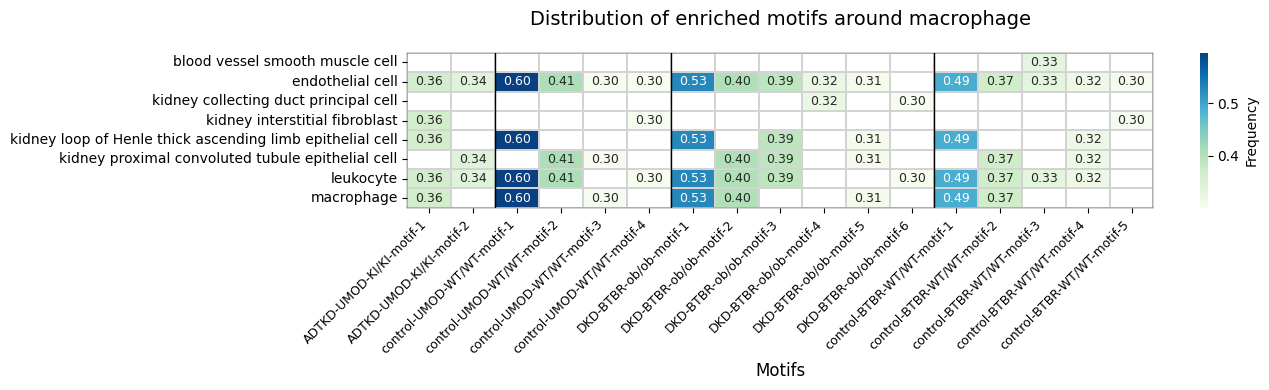

In [15]:
# Visualize enriched motifs per condition

enrich = enrich_motif_dataset_df.copy()
enrich["frequency"] = enrich["n_center_motif"] / enrich["n_center"]

# Sort by dataset, then by frequency within each dataset
enrich = enrich.sort_values(by=["dataset", "frequency"], ascending=[True, False]).reset_index(drop=True)

# Assign motif labels per dataset
enrich["motif_num"] = enrich.groupby("dataset").cumcount() + 1
enrich["motif_group"] = enrich["dataset"] + "_motif_" + enrich["motif_num"].astype(str)

# Build heatmap: cell types × motif groups
enrich_expanded = enrich.explode("motifs")
heatmap_data = enrich_expanded.pivot_table(
    index="motifs", columns="motif_group", values="frequency", aggfunc="first"
)

col_order = enrich["motif_group"].tolist()
heatmap_data = heatmap_data[col_order]
heatmap_data.columns = [col.replace("_", "-") for col in heatmap_data.columns]

# Reorder columns by condition
dataset_order = ["ADTKD-UMOD-KI/KI", "control-UMOD-WT/WT", "DKD-BTBR-ob/ob", "control-BTBR-WT/WT"]
col_order_reordered = []
for ds in dataset_order:
    col_order_reordered.extend([c for c in heatmap_data.columns if c.startswith(ds)])
heatmap_data = heatmap_data.loc[:, col_order_reordered]

# Find dataset boundaries for separator lines
boundaries = []
prev_dataset = None
for i, col in enumerate(col_order_reordered):
    current_dataset = col.split("-motif")[0]
    if prev_dataset is not None and current_dataset != prev_dataset:
        boundaries.append(i)
    prev_dataset = current_dataset

# Plot
fig, ax = plt.subplots(figsize=(max(8, len(col_order_reordered)*0.8), max(4, len(heatmap_data)*0.45)))
sns.heatmap(
    heatmap_data, cmap="GnBu", linewidths=0.25, linecolor="lightgrey",
    annot=True, fmt=".2f", annot_kws={"fontsize": 9},
    cbar_kws={"label": "Frequency"}, ax=ax,
)
for b in boundaries:
    ax.axvline(x=b, color="black", linewidth=1)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.25)
    spine.set_color("black")

plt.title(f"Distribution of enriched motifs around {anchor_ct}", fontsize=14, pad=20)
plt.ylabel("")
plt.xlabel("Motifs", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## 6. Differential Motif Analysis

Identify motifs whose frequency differs significantly between ADTKD and its control.

In [16]:
min_support = 0.5
ds_control = 'control-UMOD-WT/WT'
ds_case = 'ADTKD-UMOD-KI/KI'

diff_motif = spm.differential_analysis_dist(
    ct=anchor_ct,
    datasets=[ds_control, ds_case],
    max_dist=max_dist,
    min_support=min_support
)

Discovered 35 motifs across the datasets for differential analysis.


In [17]:
diff_motif[ds_control]

,itemsets,support_control-UMOD-WT/WT_mean,support_ADTKD-UMOD-KI/KI_mean,adj-pval


In [18]:
diff_motif[ds_case]

,itemsets,support_control-UMOD-WT/WT_mean,support_ADTKD-UMOD-KI/KI_mean,adj-pval
0,"(endothelial cell, kidney interstitial fibrobl...",0.271703,0.497934,0.002436
1,"(endothelial cell, kidney interstitial fibrobl...",0.210438,0.423196,0.002436
2,"(endothelial cell, kidney interstitial fibrobl...",0.257608,0.465558,0.002436
3,"(endothelial cell, kidney interstitial fibrobl...",0.191865,0.398037,0.003175
4,"(endothelial cell, kidney interstitial fibrobl...",0.200895,0.422659,0.003175
5,"(endothelial cell, kidney interstitial fibrobl...",0.149473,0.343525,0.004344


In [ ]:
# Verify whether differential motifs are also individually enriched within each condition
whether_significant_list = []
for m in diff_motif[ds_case]['itemsets'].values:
    m = list(m)
    out = spm.motif_enrichment_dist(
        ct=anchor_ct,
        motifs=m,
        dataset=ds_case,
        max_dist=max_dist,
    )
    whether_significant = out['if_significant'].values[0]
    whether_significant_list.append(whether_significant)

diff_motif[ds_case]['if_significant'] = whether_significant_list

In [20]:
diff_motif[ds_case]

,itemsets,support_control-UMOD-WT/WT_mean,support_ADTKD-UMOD-KI/KI_mean,adj-pval,if_significant
0,"(endothelial cell, kidney interstitial fibrobl...",0.271703,0.497934,0.002436,True
1,"(endothelial cell, kidney interstitial fibrobl...",0.210438,0.423196,0.002436,True
2,"(endothelial cell, kidney interstitial fibrobl...",0.257608,0.465558,0.002436,True
3,"(endothelial cell, kidney interstitial fibrobl...",0.191865,0.398037,0.003175,True
4,"(endothelial cell, kidney interstitial fibrobl...",0.200895,0.422659,0.003175,True
5,"(endothelial cell, kidney interstitial fibrobl...",0.149473,0.343525,0.004344,True


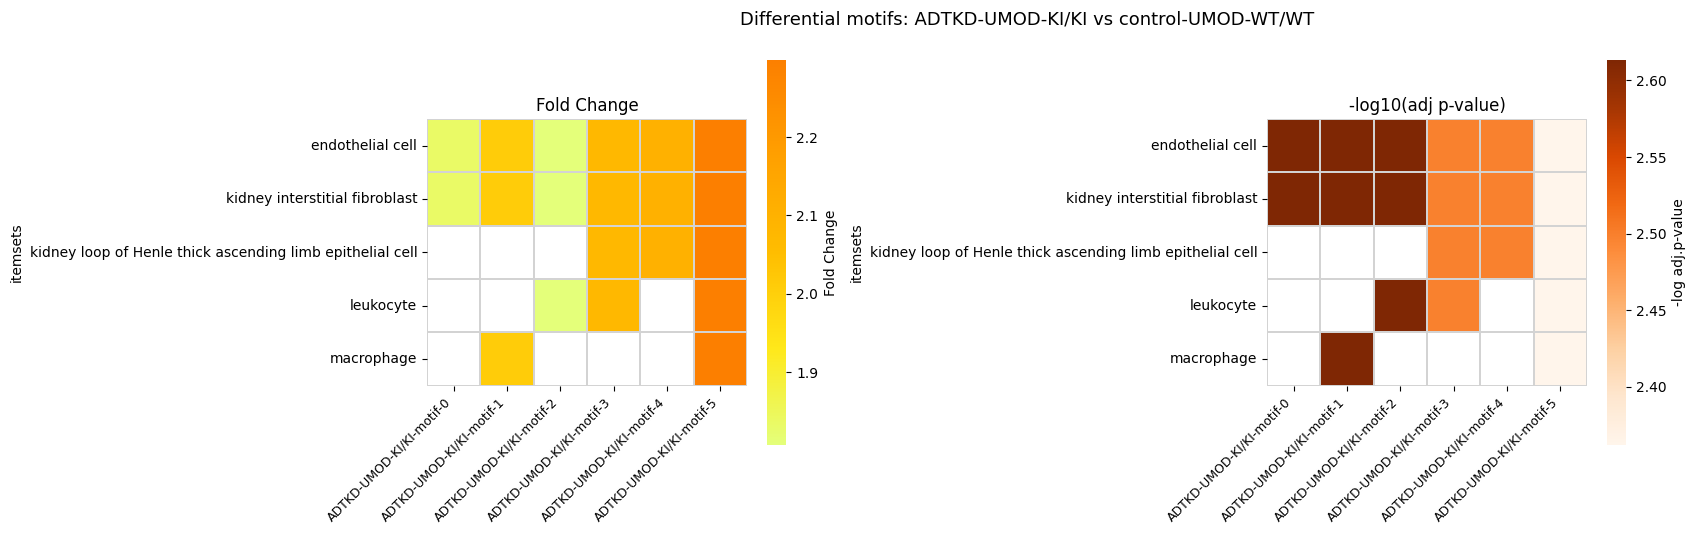

In [22]:
diff_motif[ds_case]['group'] = ds_case
diff_motif[ds_control]['group'] = ds_control

enrich = diff_motif[ds_case]
enrich = pd.concat([enrich, diff_motif[ds_control]], axis=0)

enrich['fold_change'] = enrich[f'support_{ds_case}_mean'] / enrich[f'support_{ds_control}_mean']

enrich['motif_group'] = enrich['group'] + '_motif_' + enrich.index.astype(str)
col_order = enrich['motif_group'].tolist()

enrich_expanded = enrich.explode('itemsets')

heatmap_fc = enrich_expanded.pivot_table(
    index='itemsets', columns='motif_group', values='fold_change'
)[col_order]

heatmap_pval = enrich_expanded.pivot_table(
    index='itemsets', columns='motif_group', values='adj-pval'
)
heatmap_pval = -np.log10(heatmap_pval)[col_order]

col_labels = [c.replace('_', '-') for c in col_order]
heatmap_fc.columns = col_labels
heatmap_pval.columns = col_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'wspace': 1.1})

sns.heatmap(heatmap_fc, cmap='Wistia', linewidths=0.1, linecolor='lightgrey',
            square=True, cbar_kws={'label': 'Fold Change'}, ax=ax1)
ax1.set_title('Fold Change')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=9)

sns.heatmap(heatmap_pval, cmap='Oranges', linewidths=0.1, linecolor='lightgrey',
            square=True, cbar_kws={'label': '-log adj.p-value'}, ax=ax2)
ax2.set_title('-log10(adj p-value)')
ax2.set_xlabel('')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)

fig.suptitle(f'Differential motifs: {ds_case} vs {ds_control}', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Targeted Motif Analysis

Test a specific hypothesis-driven motif (fibroblast + TAL epithelial) for differential
enrichment between ADTKD and control.

In [23]:
motif = ['kidney interstitial fibroblast', 'kidney loop of Henle thick ascending limb epithelial cell']
ds_case = 'ADTKD-UMOD-KI/KI'
ds_control = 'control-UMOD-WT/WT'

motif_enrich = spm.differential_analysis_dist(
    ct=anchor_ct,
    motifs=motif,
    datasets=[ds_control, ds_case],
    max_dist=max_dist
)



In [24]:
motif_enrich[ds_case]

,itemsets,support_control-UMOD-WT/WT_mean,support_ADTKD-UMOD-KI/KI_mean,adj-pval
0,"(kidney interstitial fibroblast, kidney loop o...",0.20119,0.42383,0.000454


In [25]:
motif_enrich[ds_control]

,itemsets,support_control-UMOD-WT/WT_mean,support_ADTKD-UMOD-KI/KI_mean,adj-pval


In [26]:
# Compute per-FOV motif frequency for statistical comparison
freq = {ds_control: [], ds_case: []}
freq_ds_names = {ds_control: [], ds_case: []}

for sp in spm.spatial_queries:
    sp_ds_name = sp.dataset.split('_')[0]
    if sp_ds_name in [ds_control, ds_case]:
        out = sp.motif_enrichment_dist(
            ct=anchor_ct, motifs=motif, max_dist=max_dist, return_cellID=False,
        )
        if len(out) == 0:
            continue
        ratio = out['n_center_motif'] / out['n_center']
        if isinstance(ratio, (pd.Series, np.ndarray)):
            ratio = ratio.iloc[0] if hasattr(ratio, 'iloc') else ratio.item()
        freq[sp_ds_name].append(float(ratio))
        freq_ds_names[sp_ds_name].append(sp.dataset)

<Axes: xlabel='group', ylabel='frequency'>

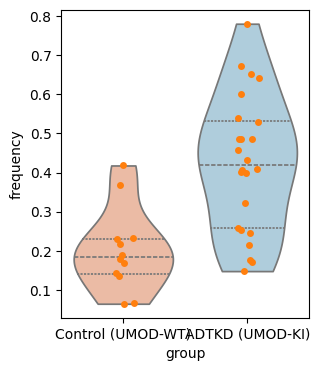

In [27]:
plot_df = pd.DataFrame({
    'group': (
        ['Control (UMOD-WT)'] * len(freq[ds_control]) +
        ['ADTKD (UMOD-KI)'] * len(freq[ds_case])
    ),
    'frequency': (
        freq[ds_control] +
        freq[ds_case]
    )
})

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(3.2, 4))

# Violin
sns.violinplot(
    data=plot_df,
    x="group",
    y="frequency",
    ax=ax,
    cut=0,
    inner="quartile",
    palette='RdBu',
)

# Overlay points
sns.stripplot(
    data=plot_df,
    x="group",
    y="frequency",
    ax=ax,
    size=5,
    jitter=0.1,
)

## 8. Spatial Visualization of Motif

Visualize the top FOVs by motif frequency for each condition.

In [28]:
def get_top3_names(freq, freq_ds_names, k=3):
    """Return dataset names of the top-k FOVs by motif frequency."""
    result = {}
    for key in freq:
        paired = sorted(zip(freq[key], freq_ds_names[key]), reverse=True)[:k]
        result[key] = [name for _, name in paired]
    return result

top3 = get_top3_names(freq, freq_ds_names)
top3

{'control-UMOD-WT/WT': ['control-UMOD-WT/WT_10',
  'control-UMOD-WT/WT_2',
  'control-UMOD-WT/WT_8'],
 'ADTKD-UMOD-KI/KI': ['ADTKD-UMOD-KI/KI_6',
  'ADTKD-UMOD-KI/KI_11',
  'ADTKD-UMOD-KI/KI_4']}

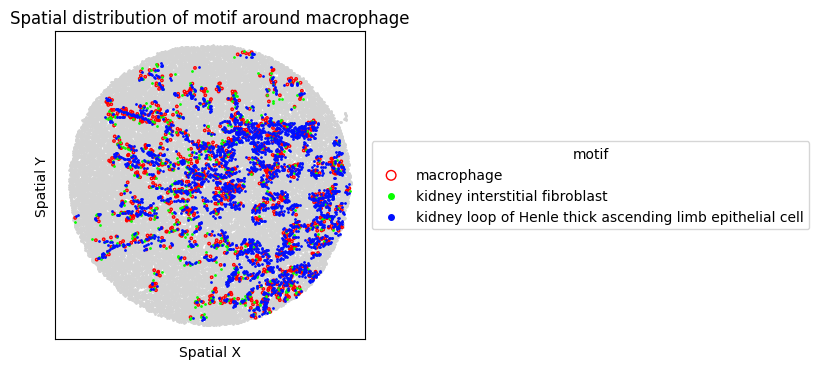

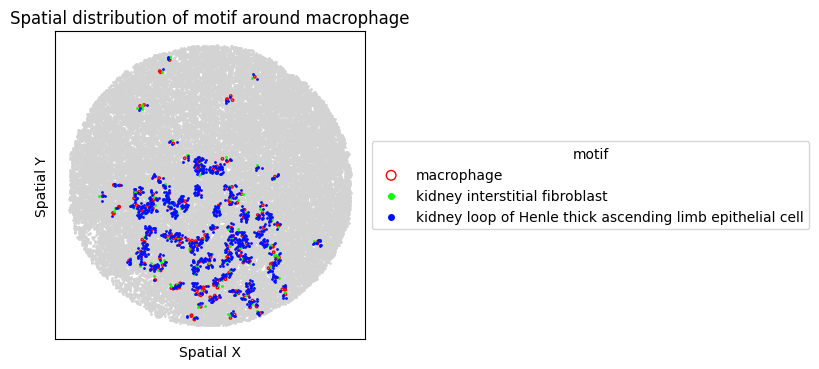

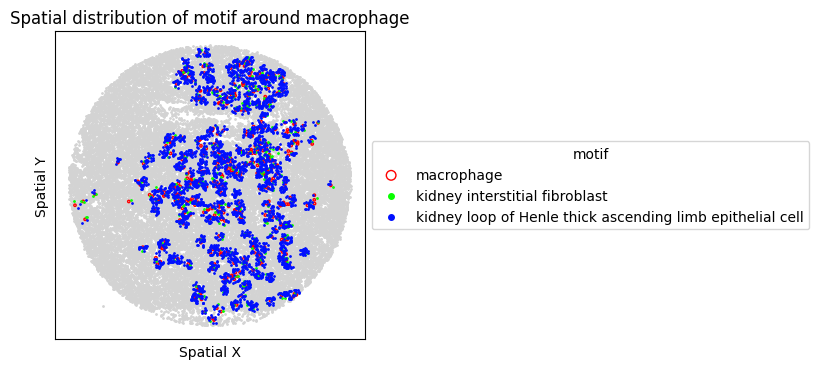

In [29]:

for sp in spm.spatial_queries:
    if sp.dataset in top3[ds_control]:
        sp.plot_motif_celltype(
            ct=anchor_ct,
            motif=motif,
            max_dist=max_dist,
            figsize=(4, 4),
        )

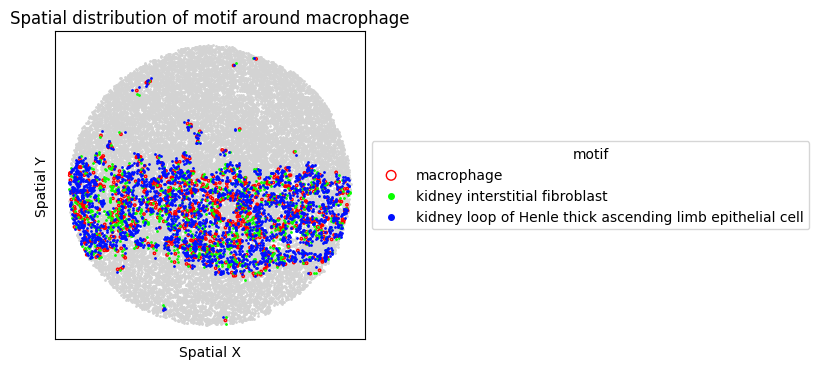

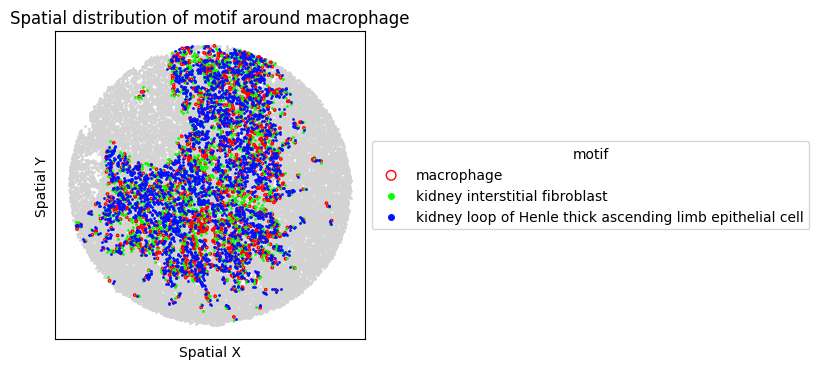

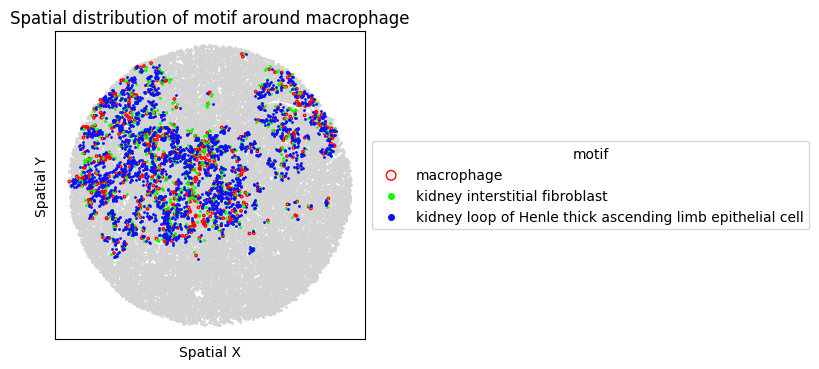

In [30]:

for sp in spm.spatial_queries:
    if sp.dataset in top3[ds_case]:
        sp.plot_motif_celltype(
            ct=anchor_ct,
            motif=motif,
            max_dist=max_dist,
            figsize=(4, 4),
        )


## 9. Differential Expression Analysis

### 9a. Motif+ Macrophages Across Conditions

Compare gene expression of motif-positive macrophages between ADTKD and control.

In [31]:
# Get cell IDs of motif-positive macrophages in each condition
ctrl_macrophage, ctrl_motif_id, ctrl_center_id = spm.motif_enrichment_dist(
    ct=anchor_ct, motifs=motif, dataset=ds_control, max_dist=max_dist, return_cellID=True,
)

adtkd_macrophage, adtkd_motif_id, adtkd_center_id = spm.motif_enrichment_dist(
    ct=anchor_ct, motifs=motif, dataset=ds_case, max_dist=max_dist, return_cellID=True,
)

In [32]:
# DE genes between motif+ macrophages in control vs ADTKD
de_genes = spm.de_genes(
    ind_group1=ctrl_center_id[str(motif)],
    ind_group2=adtkd_center_id[str(motif)],
    method='t-test',
    alpha=0.05,
)

Testing 1669 genes ...


In [33]:
de_genes

,gene,p_value,adj-pval,log2fc,proportion_1,proportion_2,abs_difference,de_in
0,Apoe,0.000000e+00,0.000000e+00,-2.901169,0.168885,0.623107,0.454222,group2
1,Mgp,0.000000e+00,0.000000e+00,-2.684509,0.119455,0.478314,0.358859,group2
2,Spp1,1.314239e-234,7.311551e-232,-1.984394,0.129278,0.372967,0.243689,group2
3,Lcn2,3.064570e-190,1.278692e-187,-4.911119,0.004119,0.119555,0.115436,group2
4,Igfbp7,1.892602e-178,6.317507e-176,-1.054887,0.517744,0.696766,0.179022,group2
...,...,...,...,...,...,...,...,...
1461,Polr2f,4.051880e-02,4.625572e-02,-0.317614,0.046261,0.060946,0.014685,group2
1462,Smarca2,4.106857e-02,4.685129e-02,-0.216650,0.093473,0.104506,0.011033,group2
1463,Abhd14b,4.160709e-02,4.743322e-02,0.279172,0.074144,0.061600,0.012544,group1
1464,Meis2,4.237911e-02,4.828036e-02,-0.273740,0.052281,0.067022,0.014741,group2


### 9b. Motif+ vs Motif− Macrophages Within ADTKD

Compare gene expression between motif-positive and motif-negative macrophages within the ADTKD condition.

In [34]:
# Get non-motif center cell IDs for each FOV in ADTKD
non_motif_center = {str(motif): {}}
for sp in spm.spatial_queries:
    if sp.dataset.split('_')[0] != ds_case:
        continue
    ct_id = np.where(sp.labels == anchor_ct)[0]
    cind_fov = adtkd_center_id[str(motif)][sp.dataset]
    print(f'number of center cells in fov {sp.dataset}: {len(cind_fov)}')
    non_motif_center[str(motif)][sp.dataset] = list(set(ct_id) - set(cind_fov))

number of center cells in fov ADTKD-UMOD-KI/KI_0: 351
number of center cells in fov ADTKD-UMOD-KI/KI_1: 161
number of center cells in fov ADTKD-UMOD-KI/KI_2: 203
number of center cells in fov ADTKD-UMOD-KI/KI_3: 143
number of center cells in fov ADTKD-UMOD-KI/KI_4: 979
number of center cells in fov ADTKD-UMOD-KI/KI_5: 165
number of center cells in fov ADTKD-UMOD-KI/KI_6: 1539
number of center cells in fov ADTKD-UMOD-KI/KI_7: 349
number of center cells in fov ADTKD-UMOD-KI/KI_8: 480
number of center cells in fov ADTKD-UMOD-KI/KI_9: 259
... (12 lines omitted) ...
number of center cells in fov ADTKD-UMOD-KI/KI_22: 271
number of center cells in fov ADTKD-UMOD-KI/KI_23: 510


In [35]:
de_genes_adtkd = spm.de_genes( 
    ind_group1=adtkd_center_id[str(motif)],
    ind_group2=non_motif_center[str(motif)],
    method='t-test',
)



Testing 1919 genes ...


In [36]:
de_genes_adtkd

,gene,p_value,adj-pval,log2fc,proportion_1,proportion_2,abs_difference,de_in
0,Kap,0.000000e+00,0.000000e+00,-1.128119,0.808843,0.901811,0.092968,group2
1,Apoe,1.884793e-259,1.808458e-256,1.029396,0.623107,0.435769,0.187338,group1
2,Aldob,4.441241e-214,2.840914e-211,-1.014052,0.317162,0.520432,0.203270,group2
3,Malat1,2.169127e-185,1.040639e-182,0.648035,0.863993,0.776140,0.087854,group1
4,Napsa,2.504258e-168,9.611342e-166,-0.932830,0.326136,0.503900,0.177765,group2
...,...,...,...,...,...,...,...,...
1269,Pak2,3.252031e-02,4.913896e-02,0.205873,0.055524,0.052315,0.003209,group1
1270,Eef1a1,3.281764e-02,4.954922e-02,-0.104386,0.174893,0.209475,0.034583,group2
1271,Tcp1,3.290753e-02,4.964588e-02,-0.165019,0.073846,0.088957,0.015112,group2
1272,Eno1,3.297983e-02,4.971587e-02,0.211290,0.052253,0.051957,0.000295,group1


## 10. Cross-cell Gene-Gene Covariation

Identify gene pairs whose expression is spatially correlated across anchor–neighbor cell pairs.

The kidney atlas data is whole-transcriptomic. We pre-select the top 3,000 highly variable
genes per condition for computational efficiency.

In [37]:
# Select top 3000 HVGs per condition and take the union
tt1 = np.array([f.replace('_','-') for f in dataset_names])
selected_genes = {}
tt2 = []
for adata in adatas:
    adata.var_names = adata.var[feature_name]
    tt2.append(adata)

for ds in valid_ds_names:
    mask = np.where(tt1 == ds)[0]
    adata_sub = ad.concat([tt2[i].copy() for i in mask], join='inner')
    print(f"{ds}: {adata_sub.shape}")
    sc.pp.normalize_total(adata_sub)
    sc.pp.log1p(adata_sub)
    sc.pp.highly_variable_genes(adata_sub, n_top_genes=3000)
    selected_genes[ds] = adata_sub.var[adata_sub.var['highly_variable']].index.tolist()

DKD-BTBR-ob/ob: (613317, 13586)
control-UMOD-WT/WT: (336157, 14271)
control-BTBR-WT/WT: (550106, 13751)
ADTKD-UMOD-KI/KI: (501021, 14390)


In [38]:
gene_pairs_by_type = spm.compute_gene_gene_correlation_by_type(
    ct=anchor_ct,
    motif=motif,
    dataset=ds_case,
    genes=selected_genes[ds_case],
    max_dist=max_dist,
    alpha=0.05,
)

gene_pairs_by_type = gene_pairs_by_type[gene_pairs_by_type['if_significant']]

Computing covarying genes using expression data ...
Analyzing 2 non-center cell types in motif: ['kidney interstitial fibroblast', 'kidney loop of Henle thick ascending limb epithelial cell']
Selected 24 FOVs for analysis
Gene coverage: 14390 genes in all FOVs, 18795 genes total (union)
  -> 4405 genes present in subset of FOVs (will use available data)
Analyzing 3000 genes across 24 FOVs

Step 1: Computing Correlation-3 (Center without motif vs Neighbors)
... (135 lines omitted) ...

Results prepared and sorted


In [39]:
gene_pairs_by_type

,cell_type,gene_center,gene_motif,corr_neighbor,corr_non_neighbor,p_value_test1,delta_corr_test1,corr_center_no_motif,p_value_test2,delta_corr_test2,combined_score,q_value_test1,q_value_test2,reject_test1_fdr,reject_test2_fdr,abs_combined_score,if_significant
0,kidney interstitial fibroblast,Wif1,Lmo3,0.815627,-0.020971,0.000000,0.836598,-0.000371,0.000000,0.815997,246.653183,0.000000,0.000000,True,True,246.653183,True
1,kidney interstitial fibroblast,Wif1,Wif1,0.786223,-0.035668,0.000000,0.821892,-0.000243,0.000000,0.786467,239.128233,0.000000,0.000000,True,True,239.128233,True
2,kidney interstitial fibroblast,Armc12,Lmo3,0.748789,-0.020264,0.000000,0.769053,-0.000078,0.000000,0.748867,226.476755,0.000000,0.000000,True,True,226.476755,True
3,kidney interstitial fibroblast,Rapgef3os1,Slamf1,0.742925,-0.017139,0.000000,0.760064,-0.000098,0.000000,0.743023,224.440595,0.000000,0.000000,True,True,224.440595,True
4,kidney interstitial fibroblast,Armc12,Wif1,0.721795,-0.034466,0.000000,0.756261,-0.000126,0.000000,0.721921,219.666989,0.000000,0.000000,True,True,219.666989,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7146,kidney loop of Henle thick ascending limb epit...,Kynu,Il12rb2,0.059978,0.000067,0.000019,0.059911,0.003008,0.000009,0.056970,0.285831,0.049627,0.026085,True,True,0.285831,True
7166,kidney loop of Henle thick ascending limb epit...,Wasf1,Pld5,0.061272,0.000150,0.000013,0.061121,0.004871,0.000011,0.056401,0.285172,0.035707,0.031025,True,True,0.285172,True
7203,kidney loop of Henle thick ascending limb epit...,Calb1,Eps8l3,0.061173,-0.000413,0.000011,0.061586,0.005089,0.000012,0.056084,0.284041,0.031473,0.034068,True,True,0.284041,True
7300,kidney loop of Henle thick ascending limb epit...,Slco1a4,Mmp7,0.060120,-0.000022,0.000018,0.060142,0.003806,0.000011,0.056314,0.280389,0.046604,0.031866,True,True,0.280389,True


In [40]:
gene_pairs_by_type['cell_type'].value_counts()

cell_type
kidney interstitial fibroblast                               2525
kidney loop of Henle thick ascending limb epithelial cell     976
Name: count, dtype: int64

Summarize the most frequent anchor and motif genes for each neighboring cell type,
focusing on positively covarying pairs.

In [41]:
fibro_pos = gene_pairs_by_type[gene_pairs_by_type['cell_type'] == 'kidney interstitial fibroblast'].copy()
fibro_pos = fibro_pos[fibro_pos['combined_score'] > 0]

tal_pos = gene_pairs_by_type[gene_pairs_by_type['cell_type'] == 'kidney loop of Henle thick ascending limb epithelial cell'].copy()
tal_pos = tal_pos[tal_pos['combined_score'] > 0]


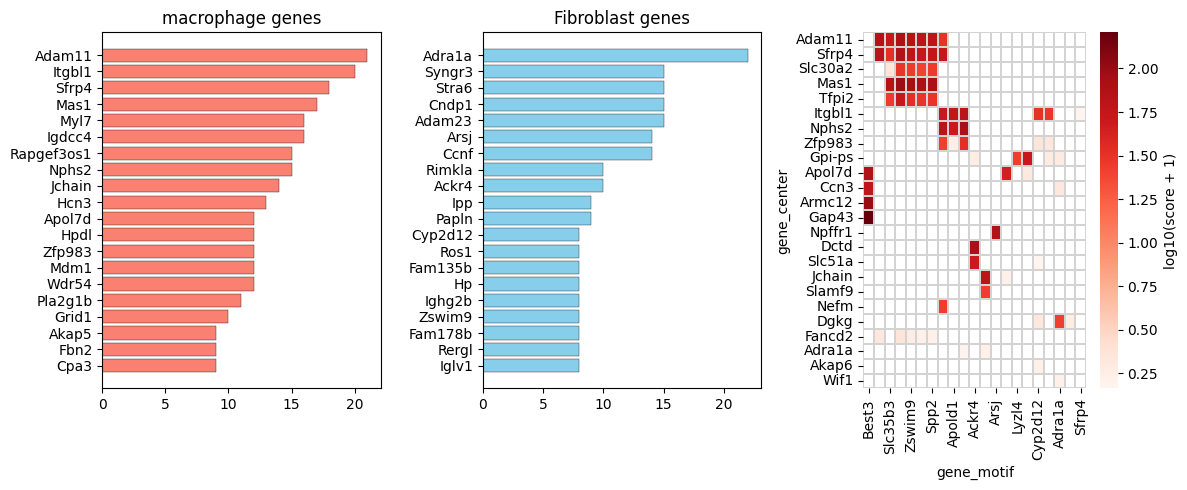

In [42]:
top_gene_center_fibro = pd.DataFrame(fibro_pos['gene_center'].value_counts().head(20))
top_gene_motif_fibro = pd.DataFrame(fibro_pos['gene_motif'].value_counts().head(20))
# reverse order 
top_gene_center_fibro = top_gene_center_fibro[::-1]
top_gene_motif_fibro = top_gene_motif_fibro[::-1]

fig, axs = plt.subplots(1, 3, figsize=(12, 5))
ax0 = axs[0]
ax1 = axs[1]
ax2 = axs[2]

ax0.barh(
    top_gene_center_fibro.index.tolist(),
    top_gene_center_fibro["count"].tolist(),
    color='salmon',
    edgecolor="black",
    linewidth=0.25
)

ax1.barh(
    top_gene_motif_fibro.index.tolist(),
    top_gene_motif_fibro["count"].tolist(),
    color='skyblue',
    edgecolor="black",
    linewidth=0.25, 
)

# ax0.set_xlabel("Count", fontsize=10)
ax0.set_title(
    f"{anchor_ct} genes",
)
# ax1.set_xlabel("Count", fontsize=10)
ax1.set_title(
    "Fibroblast genes",
)

top50_gene_center_fibro = fibro_pos['gene_center'].value_counts().head(50).index.tolist()
top50_gene_motif_fibro = fibro_pos['gene_motif'].value_counts().head(50).index.tolist()
sub_pos = fibro_pos[(fibro_pos['gene_center'].isin(top50_gene_center_fibro)) & (fibro_pos['gene_motif'].isin(top50_gene_motif_fibro))].copy()

sub_pairs_fibro_pos_pivot = sub_pos.pivot_table(
    index='gene_center',
    columns='gene_motif',
    values='combined_score',
    fill_value=0)
mask = (sub_pairs_fibro_pos_pivot == 0)

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

data = np.log10(sub_pairs_fibro_pos_pivot + 1)

# Hierarchical clustering
row_linkage = linkage(pdist(data), method='average')
col_linkage = linkage(pdist(data.T), method='average')

# Get clustered order
row_order = dendrogram(row_linkage, no_plot=True)['leaves']
col_order = dendrogram(col_linkage, no_plot=True)['leaves']

# Reorder data
data_clustered = data.iloc[row_order, col_order]
mask_clustered = mask.iloc[row_order, col_order]

# Plot heatmap
sns.heatmap(
    data_clustered, 
    cmap='Reds', 
    mask=mask_clustered,
    linewidths=0.1, 
    linecolor='lightgrey',
    cbar_kws={'label': 'log10(score + 1)'},
    ax=ax2,
)


plt.tight_layout()


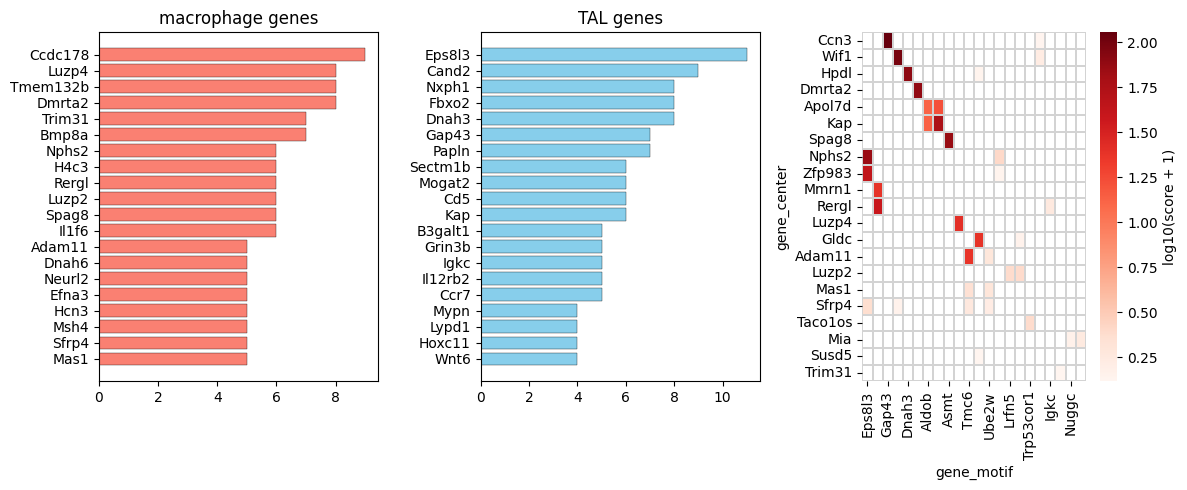

In [43]:
top_gene_center_tal = pd.DataFrame(tal_pos['gene_center'].value_counts().head(20))
top_gene_motif_tal = pd.DataFrame(tal_pos['gene_motif'].value_counts().head(20))
# reverse order 
top_gene_center_tal = top_gene_center_tal[::-1]
top_gene_motif_tal = top_gene_motif_tal[::-1]

fig, axs = plt.subplots(1, 3, figsize=(12, 5))
ax0 = axs[0]
ax1 = axs[1]
ax2 = axs[2]

ax0.barh(
    top_gene_center_tal.index.tolist(),
    top_gene_center_tal["count"].tolist(),
    color='salmon',
    edgecolor="black",
    linewidth=0.25
)

ax1.barh(
    top_gene_motif_tal.index.tolist(),
    top_gene_motif_tal["count"].tolist(),
    color='skyblue',
    edgecolor="black",
    linewidth=0.25, 
)

ax0.set_title(f"{anchor_ct} genes")
ax1.set_title("TAL genes")

top50_gene_center_tal = tal_pos['gene_center'].value_counts().head(50).index.tolist()
top50_gene_motif_tal = tal_pos['gene_motif'].value_counts().head(50).index.tolist()
sub_pos = tal_pos[(tal_pos['gene_center'].isin(top50_gene_center_tal)) & (tal_pos['gene_motif'].isin(top50_gene_motif_tal))].copy()

sub_pairs_tal_pos_pivot = sub_pos.pivot_table(
    index='gene_center',
    columns='gene_motif',
    values='combined_score',
    fill_value=0)
mask = (sub_pairs_tal_pos_pivot == 0)

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

data = np.log10(sub_pairs_tal_pos_pivot + 1)

row_linkage = linkage(pdist(data), method='average')
col_linkage = linkage(pdist(data.T), method='average')

row_order = dendrogram(row_linkage, no_plot=True)['leaves']
col_order = dendrogram(col_linkage, no_plot=True)['leaves']

data_clustered = data.iloc[row_order, col_order]
mask_clustered = mask.iloc[row_order, col_order]

sns.heatmap(
    data_clustered, 
    cmap='Reds', 
    mask=mask_clustered,
    linewidths=0.1, 
    linecolor='lightgrey',
    cbar_kws={'label': 'log10(score + 1)'},
    ax=ax2,
)


plt.tight_layout()
